Loading model from: /home/kesju/DI/ZIVEO_2025/DUOMENYS_UPD/PARAMETRAI/resunet_ecg_1024_05_31.keras
labels_all: ['clean' 'clean' 'severe' 'moderate' 'mild' 'clean' 'moderate' 'moderate'
 'mild' 'clean']
noise_level_all: [0 0 3 2 1 0 2 2 1 0]
Processed 35 files, 8348 valid segments.
261/261 [==============================] - 29s 111ms/step


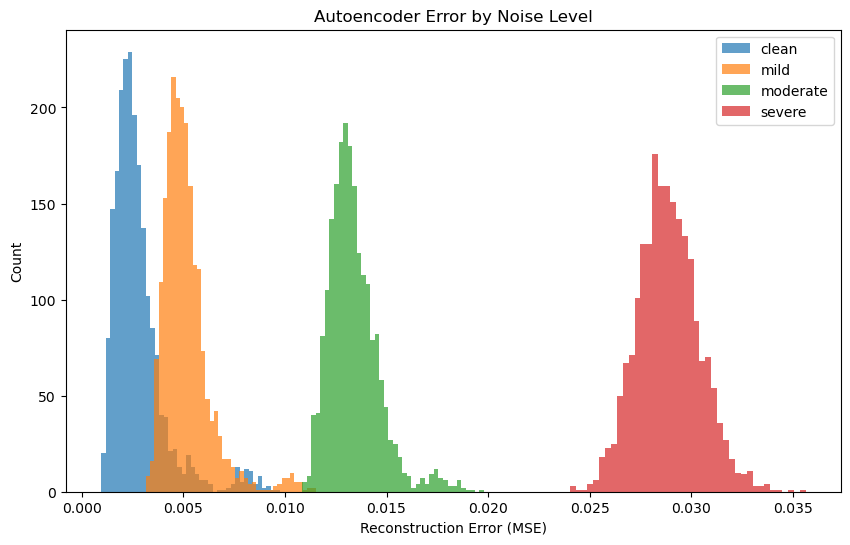


mse_thresh: 0.009

==== Binary Clean/Noisy Metrics ====
Accuracy: 0.7525155725922377
Confusion Matrix:
 [[4181 2060]
 [   6 2101]]
Classification Report:
               precision    recall  f1-score   support

       Noisy       1.00      0.67      0.80      6241
       Clean       0.50      1.00      0.67      2107

    accuracy                           0.75      8348
   macro avg       0.75      0.83      0.74      8348
weighted avg       0.87      0.75      0.77      8348

ROC AUC: 0.9772106574806115


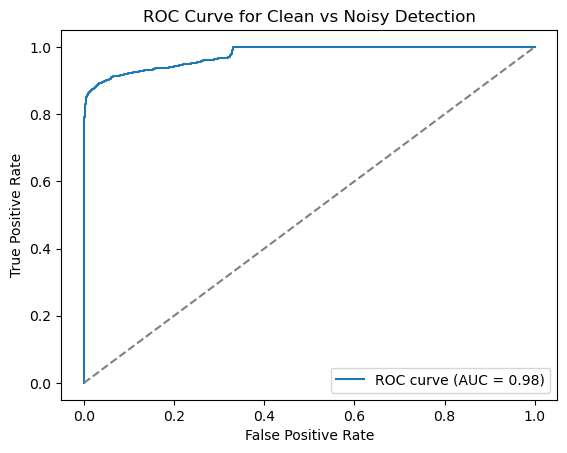


==== Multi-class Metrics (Stratified) ====
              precision    recall  f1-score   support

       clean       0.25      1.00      0.40      2107
        mild       0.00      0.00      0.00      2108
    moderate       0.00      0.00      0.00      2059
      severe       0.00      0.00      0.00      2074

    accuracy                           0.25      8348
   macro avg       0.06      0.25      0.10      8348
weighted avg       0.06      0.25      0.10      8348



/home/kesju/miniconda3/envs/zive_dask/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kesju/miniconda3/envs/zive_dask/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/kesju/miniconda3/envs/zive_dask/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.

In [ ]:
# https://chatgpt.com/c/6849ae9b-79e4-8002-b09b-47b0545f64ae

# Naudoja triukšmų lygius: 

import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from glob import glob
import json
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
import pandas as pd
from pathlib import Path

def bandpass_filter(signal, low=0.5, high=40, fs=200, order=2):
    from scipy.signal import butter, filtfilt
    b, a = butter(order, [low, high], btype='bandpass', fs=fs)
    return filtfilt(b, a, signal)

def get_noise_indices(json_path):
    if not os.path.exists(json_path):
        return []
    try:
        with open(json_path, 'r', encoding='UTF-8', errors='ignore') as f:
            data = json.load(f)
        noises = data.get('noises_annotated', [])
        return [(n['startIndex'], n['endIndex']) for n in noises]
    except Exception as e:
        print(f"Error reading {json_path}: {e}")
        return []

def segment_signal(signal, segment_length, overlap, noise_indices=None):
    if noise_indices is None:
        noise_indices = []
    step = int(segment_length * (1 - overlap))
    valid_segments = []
    indices = []
    for start in range(0, len(signal) - segment_length + 1, step):
        end = start + segment_length
        is_noisy = any(not (end <= n_start or start >= n_end) for n_start, n_end in noise_indices)
        if not is_noisy:
            valid_segments.append(signal[start:end])
            indices.append((start, end))
    return valid_segments, indices

def normalize(segment):
    mean = np.mean(segment)
    std = np.std(segment) + 1e-8
    return (segment - mean) / std

def add_stratified_noise(segment, level, fs):
    """Add noise to a segment based on the specified level (None, 'mild', 'moderate', 'severe')."""
    if level is None or level == "clean":
        return segment.copy()
    seg = segment.astype(np.float32).copy()
    params = NOISE_LEVELS[[n[0] for n in NOISE_LEVELS].index(level)][1]
    # Gaussian
    seg += np.random.normal(0, params['gauss'] * np.std(segment), segment.shape)

    # Baseline
    t = np.arange(len(seg)) / fs
    freq=0.33
    seg += params['baseline'] * np.sin(2 * np.pi * freq * t)
    
    # Powerline
    freq=50
    seg += params['powerline'] * np.sin(2 * np.pi * freq * t)
   
    # Motion
    if np.random.rand() < 0.5:
        i = 0
        prob = np.random.uniform(0.005, 0.02)
        amp = params['motion']
        dur_min, dur_max = 10, 100
        while i < len(seg):
            if np.random.rand() < prob:
                d = min(np.random.randint(dur_min, dur_max), len(seg) - i)
                seg[i:i+d] += amp * (np.random.rand() - 0.5)
                i += d
            else:
                i += 1
    return seg


# start0
Duomenu_aplankas = Path.home() / 'DI/ZIVEO_2025/DUOMENYS_UPD'
Parametru_aplankas = Duomenu_aplankas/'PARAMETRAI'

# ---- CONFIG ----
MODEL_PATH = Parametru_aplankas / 'resunet_ecg_1024_05_31.keras'
CLEAN_ECG_DIR = Duomenu_aplankas / 'train_test_ecg_mixed'
SEGMENT_LENGTH = 1024
OVERLAP = 0.5
FS = 200  # Sampling frequency

NOISE_LEVELS = [
    ("clean",   None),
    ("mild",    dict(gauss=0.03, baseline=0.05, powerline=0.05, motion=0.3)),
    ("moderate",dict(gauss=0.08, baseline=0.12, powerline=0.10, motion=0.5)),
    ("severe",  dict(gauss=0.15, baseline=0.25, powerline=0.15, motion=1.2))
]

#  mse_thresh = 0.15  # Choose threshold visually!
mse_thresh = 0.008  # Choose threshold visually!
mse_thresh = 0.009  # Choose threshold visually!


# gauss = gaussian_std_ratio
# baseline = baseline_amp, baseline_freq': 0.33
# powerline = powerline_amp, powerline_freq: 50
# motion = motion_amp
# prob =motion_prob = np.random.uniform(0.002, 0.015)
# dur_min, dur_max = motion_duration_min, motion_duration_max = 10, 100

# training script used these parameters:
# 'gaussian_std_ratio': np.random.uniform(0.03, 0.15),      # mild to strong Gaussian
# 'baseline_amp': np.random.uniform(0.05, 0.25),            # mild to strong baseline
# 'baseline_freq': 0.33,                                    # can randomize if you want
# 'powerline_amp': np.random.uniform(0.05, 0.15),           # mild to strong powerline
# 'powerline_freq': 50.0,                                   # can be 60.0 if needed
# 'motion_amp': np.random.uniform(0.3, 1.2),                # mild to strong artifact
# 'motion_prob': np.random.uniform(0.002, 0.015),           # rare to common artifact
# 'motion_duration_min': 10,
# 'motion_duration_max': 100


NOISE_LEVEL_LABELS = [n[0] for n in NOISE_LEVELS]

print(f"Loading model from: {MODEL_PATH}")
autoencoder = keras.models.load_model(MODEL_PATH, compile=False)

# ---- Build stratified dataset ----
segments_all, labels_all, noise_level_all = [], [], []
file_count = 0
for fpath in glob(os.path.join(CLEAN_ECG_DIR, "*.npy")):
    sig = np.load(fpath)
    sig_filt = bandpass_filter(sig, low=0.5, high=40, fs=FS, order=2)
    json_path = os.path.splitext(fpath)[0] + ".json"
    noise_indices = get_noise_indices(json_path)
    segs, _ = segment_signal(sig_filt, SEGMENT_LENGTH, OVERLAP, noise_indices)
    file_count += 1

    for seg in segs:
        seg_norm = normalize(seg)    # Normalize before adding noise
        # Randomly assign noise level (evenly for all 4 classes)
        noise_level_idx = np.random.choice(len(NOISE_LEVELS))
        noise_label = NOISE_LEVELS[noise_level_idx][0]
        seg_noised = add_stratified_noise(seg_norm, noise_label, fs=FS)
        seg_noised_norm = normalize(seg_noised)  # Normalize noisy segment for inference
        segments_all.append(seg_noised_norm)
        labels_all.append(noise_label)
        noise_level_all.append(noise_level_idx)

segments_all = np.stack(segments_all)
labels_all = np.array(labels_all)
print(f"labels_all: {labels_all[:10]}")
noise_level_all = np.array(noise_level_all)
print(f"noise_level_all: {noise_level_all[:10]}")
print(f"Processed {file_count} files, {len(segments_all)} valid segments.")

# ---- Autoencoder Inference ----
segments_input = segments_all[..., np.newaxis]
recons = autoencoder.predict(segments_input, verbose=1)
recons = recons.squeeze()

# ---- Reconstruction Error ----
mse = np.mean((segments_all - recons) ** 2, axis=1)

# ---- Visualization ----
plt.figure(figsize=(10, 6))
for i, label in enumerate(NOISE_LEVEL_LABELS):
    plt.hist(mse[labels_all == label], bins=40, alpha=0.7, label=label)
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Count")
plt.legend()
plt.title("Autoencoder Error by Noise Level")
plt.show()

# ---- Metrics: Example for "clean" vs ("mild"|"moderate"|"severe") ----
is_clean = (labels_all == "clean")
is_noisy = ~is_clean

pred_clean = mse < mse_thresh
print("\nmse_thresh:", mse_thresh)
print("\n==== Binary Clean/Noisy Metrics ====")
print("Accuracy:", accuracy_score(is_clean, pred_clean))
print("Confusion Matrix:\n", confusion_matrix(is_clean, pred_clean))
print("Classification Report:\n", classification_report(is_clean, pred_clean, target_names=["Noisy", "Clean"]))
print("ROC AUC:", roc_auc_score(is_clean, mse*-1))

fpr, tpr, _ = roc_curve(is_clean, mse*-1)
plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(is_clean, mse*-1):.2f})')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Clean vs Noisy Detection')
plt.legend()
plt.show()

# ---- Multi-class metrics ----
print("\n==== Multi-class Metrics (Stratified) ====")
print(classification_report(labels_all, pd.cut(mse, bins=[-np.inf, 0.04, 0.08, 0.13, np.inf], labels=NOISE_LEVEL_LABELS)))
